In [1]:
import os
import random
from pathlib import Path
import numpy as np
from PIL import Image
import pandas as pd
import math

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as T

from transformers import AutoImageProcessor, AutoModel

from concurrent.futures import ThreadPoolExecutor, as_completed
from pycocotools.coco import COCO
from tqdm.auto import tqdm

# ----- SETTINGS -----
DATA_ROOT = Path("/kaggle/input/plantseg/plantsegv2")
ANN_FILE  = DATA_ROOT / "coco_annotations.json"
IMG_ROOT  = DATA_ROOT / "images"
DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"

IMAGE_SIZE = 384
BATCH_SIZE = 4
EPOCHS = 5
LR = 1e-3
FREEZE_BACKBONE = True

MODEL_DIR = "/root/.cache/modelscope/hub/models/facebook/dinov3-vitb16-pretrain-lvd1689m"

2026-02-16 14:41:00.933513: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771252861.084478     242 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771252861.127499     242 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771252861.497869     242 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771252861.497912     242 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771252861.497915     242 computation_placer.cc:177] computation placer alr

In [2]:
!pip install modelscope
!modelscope download --model facebook/dinov3-vitb16-pretrain-lvd1689m
# /root/.cache/modelscope/hub/models/facebook/dinov3-vitb16-pretrain-lvd1689m


 _   .-')                _ .-') _     ('-.             .-')                              _ (`-.    ('-.
( '.( OO )_             ( (  OO) )  _(  OO)           ( OO ).                           ( (OO  ) _(  OO)
 ,--.   ,--.).-'),-----. \     .'_ (,------.,--.     (_)---\_)   .-----.  .-'),-----.  _.`     \(,------.
 |   `.'   |( OO'  .-.  ',`'--..._) |  .---'|  |.-') /    _ |   '  .--./ ( OO'  .-.  '(__...--'' |  .---'
 |         |/   |  | |  ||  |  \  ' |  |    |  | OO )\  :` `.   |  |('-. /   |  | |  | |  /  | | |  |
 |  |'.'|  |\_) |  |\|  ||  |   ' |(|  '--. |  |`-' | '..`''.) /_) |OO  )\_) |  |\|  | |  |_.' |(|  '--.
 |  |   |  |  \ |  | |  ||  |   / : |  .--'(|  '---.'.-._)   \ ||  |`-'|   \ |  | |  | |  .___.' |  .--'
 |  |   |  |   `'  '-'  '|  '--'  / |  `---.|      | \       /(_'  '--'\    `'  '-'  ' |  |      |  `---.
 `--'   `--'     `-----' `-------'  `------'`------'  `-----'    `-----'      `-----'  `--'      `------'


Successfully Downloaded from model facebook/dinov3-v

In [4]:
class PlantSegCOCODataset(Dataset):
    SPLIT_MAP = {
        "train": "Training",
        "val": "Validation",
        "test": "Test",
    }

    def __init__(
        self,
        data_root,
        coco_ann_file,
        split="train",
        size=(384, 384),
        model_dir=None,
        num_workers=3
    ):
        self.data_root = Path(data_root)
        self.size = size
        self.split = split.lower()
        self.num_workers = num_workers

        # --- Load metadata ---
        metadata_path = self.data_root / "Metadatav2.csv"
        df = pd.read_csv(metadata_path)
        split_name = self.SPLIT_MAP[self.split]
        self.df = df[df["Split"] == split_name].reset_index(drop=True)

        # --- COCO ---
        self.coco = COCO(str(coco_ann_file))
        self.filename_to_coco_id = {im["file_name"]: im["id"] for im in self.coco.dataset["images"]}

        # --- HF image processor ---
        self.processor = AutoImageProcessor.from_pretrained(
            model_dir,
            size={"height": size[0], "width": size[1]},
            do_resize=True,
            local_files_only=True,
        )

        # --- Preload images and masks in parallel ---
        self.images = [None] * len(self.df)
        self.masks = [None] * len(self.df)
        print(f"Preloading {len(self.df)} images with {self.num_workers} workers...")

        def load_single(idx_row):
            idx, row = idx_row
            img_path = self.data_root / "images" / self.split / row["Name"]
            mask_path = self.data_root / "annotations" / self.split / row["Label file"]

            # Load and process
            img = Image.open(img_path).convert("RGB")
            img = img.resize(self.size, Image.BILINEAR)
            pixel_values = self.processor(images=img, return_tensors="pt").pixel_values.squeeze(0)
            
            mask = Image.open(mask_path).convert("L")
            # print(np.unique(mask))
            # mask_np = (np.array(mask) > 0).astype(np.uint8)
            mask_np = np.array(mask, dtype=np.uint8) # multiclass waow
            mask_resized = Image.fromarray(mask_np).resize(self.size, Image.NEAREST)
            mask_np = np.array(mask_resized, dtype=np.uint8)
            mask_tensor = torch.from_numpy(mask_np)
            return idx, pixel_values, mask_tensor

        # Parallel loading with progress bar
        with ThreadPoolExecutor(max_workers=self.num_workers) as executor:
            futures = {executor.submit(load_single, idx_row): idx_row for idx_row in self.df.iterrows()}
            for future in tqdm(as_completed(futures), total=len(futures), desc="Loading images"):
                idx, pixel_values, mask_tensor = future.result()
                self.images[idx] = pixel_values
                self.masks[idx] = mask_tensor

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.masks[idx]

In [5]:
# ----------------------
# Simple decoder
# ----------------------
class SimpleDecoder(nn.Module):
    def __init__(self, in_channels, nc=1):
        super().__init__()
        self.decode = nn.Sequential(
            nn.Conv2d(in_channels, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, nc, kernel_size=1)
        )

    def forward(self, x):
        return self.decode(x)

# ----------------------
# DINOv3 segmentation model
# ----------------------
class Dinov3Segmentation(nn.Module):
    def __init__(self, backbone_path, num_classes=1, fine_tune=False):
        super().__init__()
        print(f"Loading backbone from {backbone_path}")
        self.backbone = AutoModel.from_pretrained(str(backbone_path), local_files_only=True)
        self.num_classes = num_classes

        # freeze or fine-tune
        for p in self.backbone.parameters():
            p.requires_grad = fine_tune

        hidden_dim = self.backbone.config.hidden_size
        self.decode_head = SimpleDecoder(in_channels=hidden_dim, nc=self.num_classes)

    def forward(self, x):
        # get patch features from backbone
        outputs = self.backbone(x, output_hidden_states=False)
        all_tokens = outputs.last_hidden_state
    
        # DINOv3 specifics
        num_class_tokens = 1
        num_register_tokens = 4  # adjust if your model differs
        tokens = all_tokens[:, num_class_tokens+num_register_tokens:, :]  # keep only patch tokens
    
        B, P, C = tokens.shape
        Hf = Wf = int(math.sqrt(P))
        assert Hf*Wf == P, f"Patch tokens do not form a square grid"
        feats = tokens.permute(0, 2, 1).reshape(B, C, Hf, Wf)
    
        # decode to segmentation mask
        seg = nn.functional.interpolate(
            self.decode_head(feats),
            size=(IMAGE_SIZE, IMAGE_SIZE),
            mode="bilinear",
            align_corners=False
        )
        return seg


In [6]:
train_ds = PlantSegCOCODataset(DATA_ROOT, ANN_FILE, split="train", size=(IMAGE_SIZE,IMAGE_SIZE), model_dir=MODEL_DIR)
val_ds = PlantSegCOCODataset(DATA_ROOT, ANN_FILE, split="val", size=(IMAGE_SIZE,IMAGE_SIZE), model_dir=MODEL_DIR)

loading annotations into memory...
Done (t=2.96s)
creating index...
index created!
Preloading 7916 images with 3 workers...


Loading images:   0%|          | 0/7916 [00:00<?, ?it/s]

loading annotations into memory...
Done (t=2.26s)
creating index...
index created!
Preloading 1247 images with 3 workers...


Loading images:   0%|          | 0/1247 [00:00<?, ?it/s]

: 

: 

: 

In [ ]:
# # few-shot
# indices = list(range(len(train_ds)))
# random.shuffle(indices)
NUM_CLASSES = 115

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

model = Dinov3Segmentation(MODEL_DIR, num_classes=NUM_CLASSES, fine_tune=False).to(DEVICE)

optimizer = torch.optim.Adam(model.decode_head.parameters(), lr=LR)
# criterion = nn.BCEWithLogitsLoss()
criterion = nn.CrossEntropyLoss()

for ep in range(1):
    model.train()
    total_loss = 0
    for imgs, masks in tqdm(train_loader, desc=f"Epoch {ep}"):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        preds = model(imgs)
        # loss = criterion(preds, masks)
        masks = masks.long().to(DEVICE)
        loss = criterion(preds, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
    print(f"[Epoch {ep}] Train loss: {total_loss/len(train_loader):.4f}")

    # val
    # model.eval()
    # ious = []
    # with torch.no_grad():
    #     for imgs, masks in val_loader:
    #         imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
    #         preds = model(imgs)
    #         # pred_mask = (torch.sigmoid(preds) > 0.5).float()
    #         pred_mask = torch.argmax(preds, dim=1)  # (B,H,W)
    #         inter = (pred_mask * masks).sum(dim=(1,2,3))
    #         union = ((pred_mask + masks) >= 1).float().sum(dim=(1,2,3))
    #         ious.extend((inter/(union+1e-6)).cpu().numpy())
    # print(f"[Epoch {ep}] Val mIoU: {np.mean(ious):.4f}")
    model.eval()
    ious = []
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(DEVICE)
            masks = masks.to(DEVICE).long()   # (B,H,W)
            preds = model(imgs)               # (B,C,H,W)
            pred_mask = torch.argmax(preds, dim=1)  # (B,H,W)
            batch_ious = []
            for cls in range(1, NUM_CLASSES):
                pred_c = (pred_mask == cls)
                gt_c   = (masks == cls)
                inter = (pred_c & gt_c).sum(dim=(1,2))
                union = (pred_c | gt_c).sum(dim=(1,2))
                iou = inter.float() / (union.float() + 1e-6)
                batch_ious.append(iou)
            if len(batch_ious) > 0:
                batch_ious = torch.stack(batch_ious, dim=1)  # (B,num_classes-1)
                ious.extend(batch_ious.mean(dim=1).cpu().numpy())
    print(f"[Epoch {ep}] Val mIoU: {np.mean(ious):.4f}")


# save decoder
torch.save(model.decode_head.state_dict(), "dinov3_plantseg_head.pth")
print("Saved decoder head.")

Loading backbone from /root/.cache/modelscope/hub/models/facebook/dinov3-vitb16-pretrain-lvd1689m


Epoch 0:   0%|          | 0/1979 [00:00<?, ?it/s]

[Epoch 0] Train loss: 1.0388
[Epoch 0] Val mIoU: 0.4575
Saved decoder head.


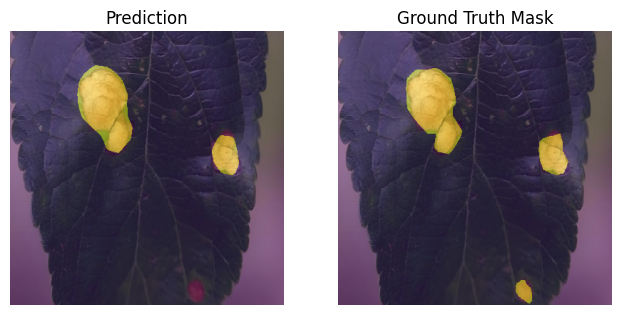

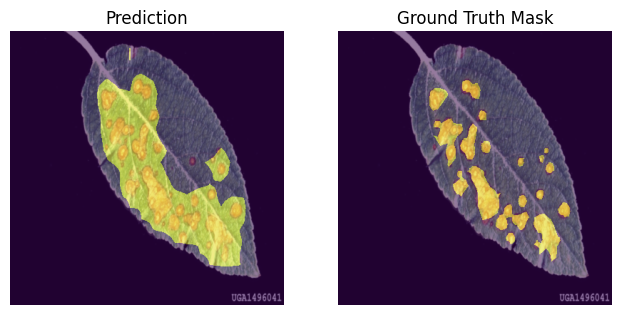

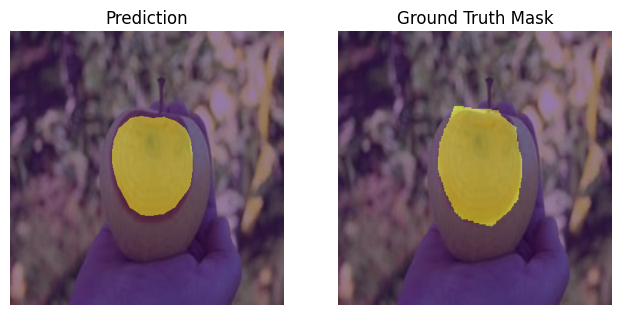

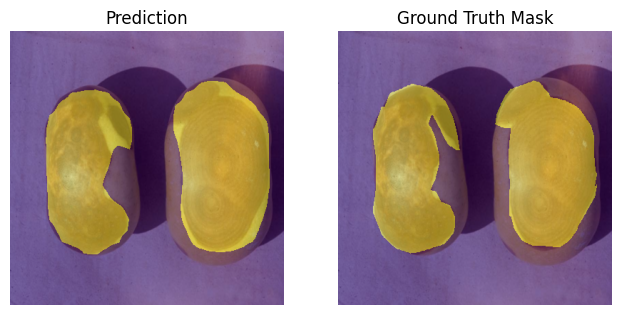

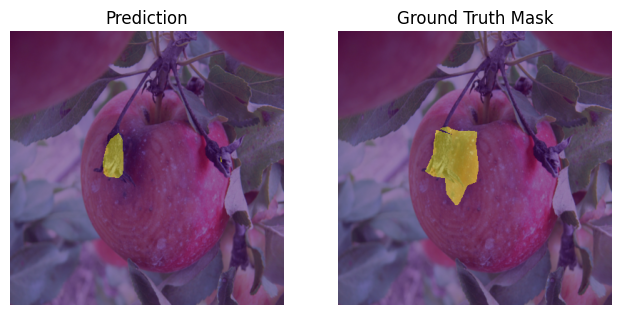

In [10]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Pick some images from validation set
model.eval().to(DEVICE)
with torch.no_grad():
    for i in range(5):
        img, mask = val_ds[i]  # your PlantSegCOCODataset returns (pixel_values, mask)
        x = img.unsqueeze(0).to(DEVICE)
        pred = model(x)  # (1, 1, H, W)
        pred_sigmoid = torch.sigmoid(pred).squeeze().cpu().numpy()

        # Original image for display
        img_disp = img.permute(1,2,0).cpu().numpy()  # C,H,W -> H,W,C
        img_disp = (img_disp - img_disp.min()) / (img_disp.max() - img_disp.min())

        mask_np = mask.squeeze().cpu().numpy()

        plt.figure(figsize=(12,4))
        plt.subplot(1,3,1)
        plt.title("Prediction")
        plt.imshow(img_disp)
        pred_bin = (pred_sigmoid > 0.5).astype(np.uint8)
        plt.imshow(pred_bin, alpha=0.5)  # semi-transparent overlay
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.title("Ground Truth Mask")
        plt.imshow(img_disp)
        plt.imshow(mask_np, alpha=0.5)  # semi-transparent overlay
        plt.axis("off")
        plt.show()
